In [46]:
# =================================================================================================
# Simulación del proceso de Difusion (lambda,F)-Wright-Fisher
# Autor: Rodolfo Escamilla Lara
# Descripción: Este script simula una trayectoria del modelo de Difusion (lambda,F)-Wright-Fisher
# con mutacion mediante el metodo de Euler-Maruyama
# =================================================================================================

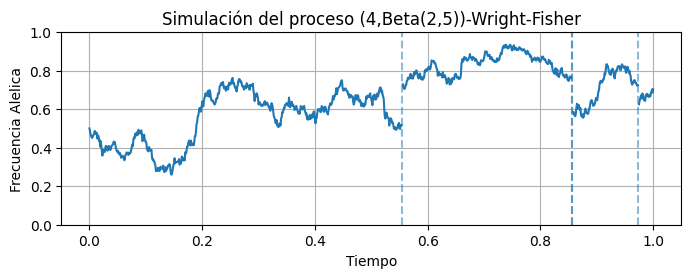

In [47]:
#Importamos las librerias que utilizaremos en el script
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import arcsine

# =======================================================================================
# Parámetros generales
# =======================================================================================

T = 1    # Intervalo de tiempo por la que simularemos nuestro Wright-Fisher
dt = 0.001   # Partiremos de manera homogenea el intervalo (T) cada uno de tamaño dt
num_pasos = int(T / dt) # Numero de intervalos que parten el tiempo T
N = int(1/dt) # Numero de la poblacion
gamma = 0.001   # Probabilidad de mutacion de un alelo del tipo (A2) hacia un alelo del tipo (A1)
alpha = 0.001   # Probabilidad de mutacion de un alelo de tipo (A1) hacia un alelo de tipo (A2)
delta = N*gamma      # Intensidad de mutacion de (A_2) hacia (A_1)
beta = N*alpha      # Intensidad de mutacion de (A_1) hacia (A_2)
valores_quitar = [] # Aqui guardaremos los valores donde ocurre un salto y que quitaremos para visualizar el salto


# ==============================================================================
# Parámetros del proceso de Poisson y de la v.a R si es que necestia parametros
# ==============================================================================

lamda = 4       # eventos por unidad de tiempo
a = 2           # Parametros de la v.a R si es que los necesita
b = 5

# ============================================================
# Tiempo y trayectoria
# ============================================================

t = np.linspace(0, T, num_pasos + 1)
x = np.zeros(num_pasos + 1)
x[0] = 0.5     # Condición inicial

# ============================================================
# Simular tiempos de salto del proceso de Poisson
# ============================================================

def simular_proceso_poisson(lamda, T):

    tiempos = []
    tiempo = 0.0

    while True:

        # Tiempo entre eventos ~ Exp(lamda)
        tiempo_entre_eventos = np.random.exponential(1 / lamda)

        tiempo += tiempo_entre_eventos

        if tiempo > T:
            break

        tiempos.append(tiempo)

    return np.array(tiempos)


eventos = simular_proceso_poisson(lamda, T)

# ================================================================================================
# Simulación de la difusion (4,Beta(2,5))-Wright-Fisher por metodo de Euler-maruyama
# Si usas otra v.a para R o otro lambda del poisson esos parametros se cambian por las que se usen
# ================================================================================================

j = 0 # Índice del proximo evento contabiliza las ocurrencias

for i in range(num_pasos):

    drift = delta * (1 - x[i]) - beta * x[i]
    diffusion = np.sqrt(max(0, x[i] * (1 - x[i])))
    dB = np.random.normal(0, np.sqrt(dt))
    x[i+1] = x[i] + drift * dt + diffusion * dB
    x[i+1] = min(1, max(0, x[i+1])) # Evitar salir de [0,1]

    # ========================================================
    #  Revisar si ocurrió un salto en este intervalo
    # ========================================================

    tiempo_actual = t[i+1]

    if j < len(eventos) and tiempo_actual >= eventos[j]:

        # Valor justo antes del salto
        x_antes = x[i+1]


        # Nuevo tamaño de salto R_i
        R = np.random.beta(a, b)

        # Nueva variable uniforme U_i
        U = np.random.uniform(0, 1)

        # Regla de salto:
        # X_T = (1-R) X_T- + R 1_{U <= X_T-}

        indicador = 1 if U <= x_antes else 0
        x_despues = (1 - R) * x_antes + R * indicador
        x[i+1] = x_despues  # Actualizamos el valor
        valores_quitar.append(i+1)

        j += 1 # Pasamos al siguiente evento


# ============================================================
# Plot de la difusion
# ============================================================

for i in valores_quitar:
    x[i]= np.nan

plt.figure(figsize=(8, 2.5))
plt.plot(t, x)

# Marcar los tiempos de salto
for evento in eventos:
    plt.axvline(evento, linestyle="--", alpha=0.5)

plt.xlabel("Tiempo")
plt.ylabel("Frecuencia Alelica")
plt.title("Simulación del proceso (4,Beta(2,5))-Wright-Fisher")
plt.ylim(0, 1)
plt.grid()
plt.savefig("lambdaBeta-wright-fisher_alpha_001_gamma_001.png", dpi=300, bbox_inches="tight")
plt.show()